<span style="font-size:16px">First we import our libraries</span>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from IPython.display import display

In [2]:
data=pd.read_csv("water_potability.csv")
df=pd.DataFrame(data)
df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


with the use of isnull and sum we fint all missing values

In [3]:
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

with this method we can find the percentage of the missing values so we can decide what to do

In [19]:
percentMissing=df.isnull().sum()*100/len(df)
missings=pd.DataFrame({"column":df.columns,
                    "missing-amount":percentMissing})
percent=pd.DataFrame(missings)
percent

,column,missing-amount
ph,ph,14.987790
Hardness,Hardness,0.000000
Solids,Solids,0.000000
Chloramines,Chloramines,0.000000
Sulfate,Sulfate,23.840049
Conductivity,Conductivity,0.000000
Organic_carbon,Organic_carbon,0.000000
Trihalomethanes,Trihalomethanes,4.945055
Turbidity,Turbidity,0.000000
Potability,Potability,0.000000


it shows how many rows have missing values 

In [20]:
rowsMv=df.isna().any(axis=1).sum()
print(rowsMv)

1265


In [21]:
allrows=len(df)
mvPercent=(rowsMv/allrows)*100
print(mvPercent)

38.614163614163616


with this simple knn function we enter almost correct data in to the parts that are missing

In [22]:
def simple_knn(df,target_col,k=10):
    df=df.copy()
    feature_cols=[
        col for col in df.columns
        if col != target_col and df[col].isna().sum() == 0
    ]
    shown = 0
    known=df[df[target_col].notna()]
    missing=df[df[target_col].isna()]
    
    for idx,row in missing.iterrows():
        diffs=known[feature_cols].sub(row[feature_cols]).abs()
        distances=diffs.sum(axis=1)
        nearest_idx=distances.nsmallest(k).index
        imputed_value=known.loc[nearest_idx, target_col].mean()
        df.at[idx, target_col]= imputed_value

    return df

In [23]:
df1=simple_knn(df,"ph",k=10)
df1.isnull().sum()

ph                   0
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [24]:
df2=simple_knn(df1,"Sulfate",k=10)
df2.isnull().sum()

ph                   0
Hardness             0
Solids               0
Chloramines          0
Sulfate              0
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

here i needed collumns names just to speed things up 

In [25]:
finall_df=simple_knn(df2,"Trihalomethanes",k=10)
finall_df.isnull().sum()
finall_df.columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='object')

i decided to compare all the collumns with ph to see if a water sample is drinkable
as you can see in the first lane "ph_hardness" i found all rows that pass my condition and got the result as a bolean
for instance  base on my search and the provided pdf i needed to find samples of ph and Hardness values that are between 6 to 8.5
and 120 to 170 respectively

In [26]:
ph_hardness=((finall_df["ph"].between(6,8.5))&(finall_df["Hardness"].between(120,170)))
ph_solids=((finall_df["ph"].between(6,8.5))&(finall_df["Solids"].between(30000,60000)))
ph_chloramines=((finall_df["ph"].between(6,8.5))&(finall_df["Chloramines"].between(0,4)))
ph_sulfate=((finall_df["ph"].between(6,8.5))&(finall_df["Sulfate"].between(250,450)))
ph_conductivity=((finall_df["ph"].between(6,8.5))&(finall_df["Conductivity"].between(250,500)))
ph_carbon=((finall_df["ph"].between(6,8.5))&(finall_df["Organic_carbon"].between(1,4)))
ph_trihalomethanes=((finall_df["ph"].between(6,8.5))&(finall_df["Trihalomethanes"].between(1,80)))
ph_turbidity=((finall_df["ph"].between(6,8.5))&(finall_df["Turbidity"].between(0.9,4)))

i wanted to use a loop for this part but it was too soon for me i gues.so i did it in the old fashion simple way.
created sub plots with my desierd size and dpi.
i did one plot in orange with normall data wich had lots of wrong information 
afterwards i did another plot with blue dots wich shows the potable waters samples that passed my filters
i also highlihte the safe ranges for every chemical that should be in daily drinking water.
im new to this so i think colors i ve choosen are not great 

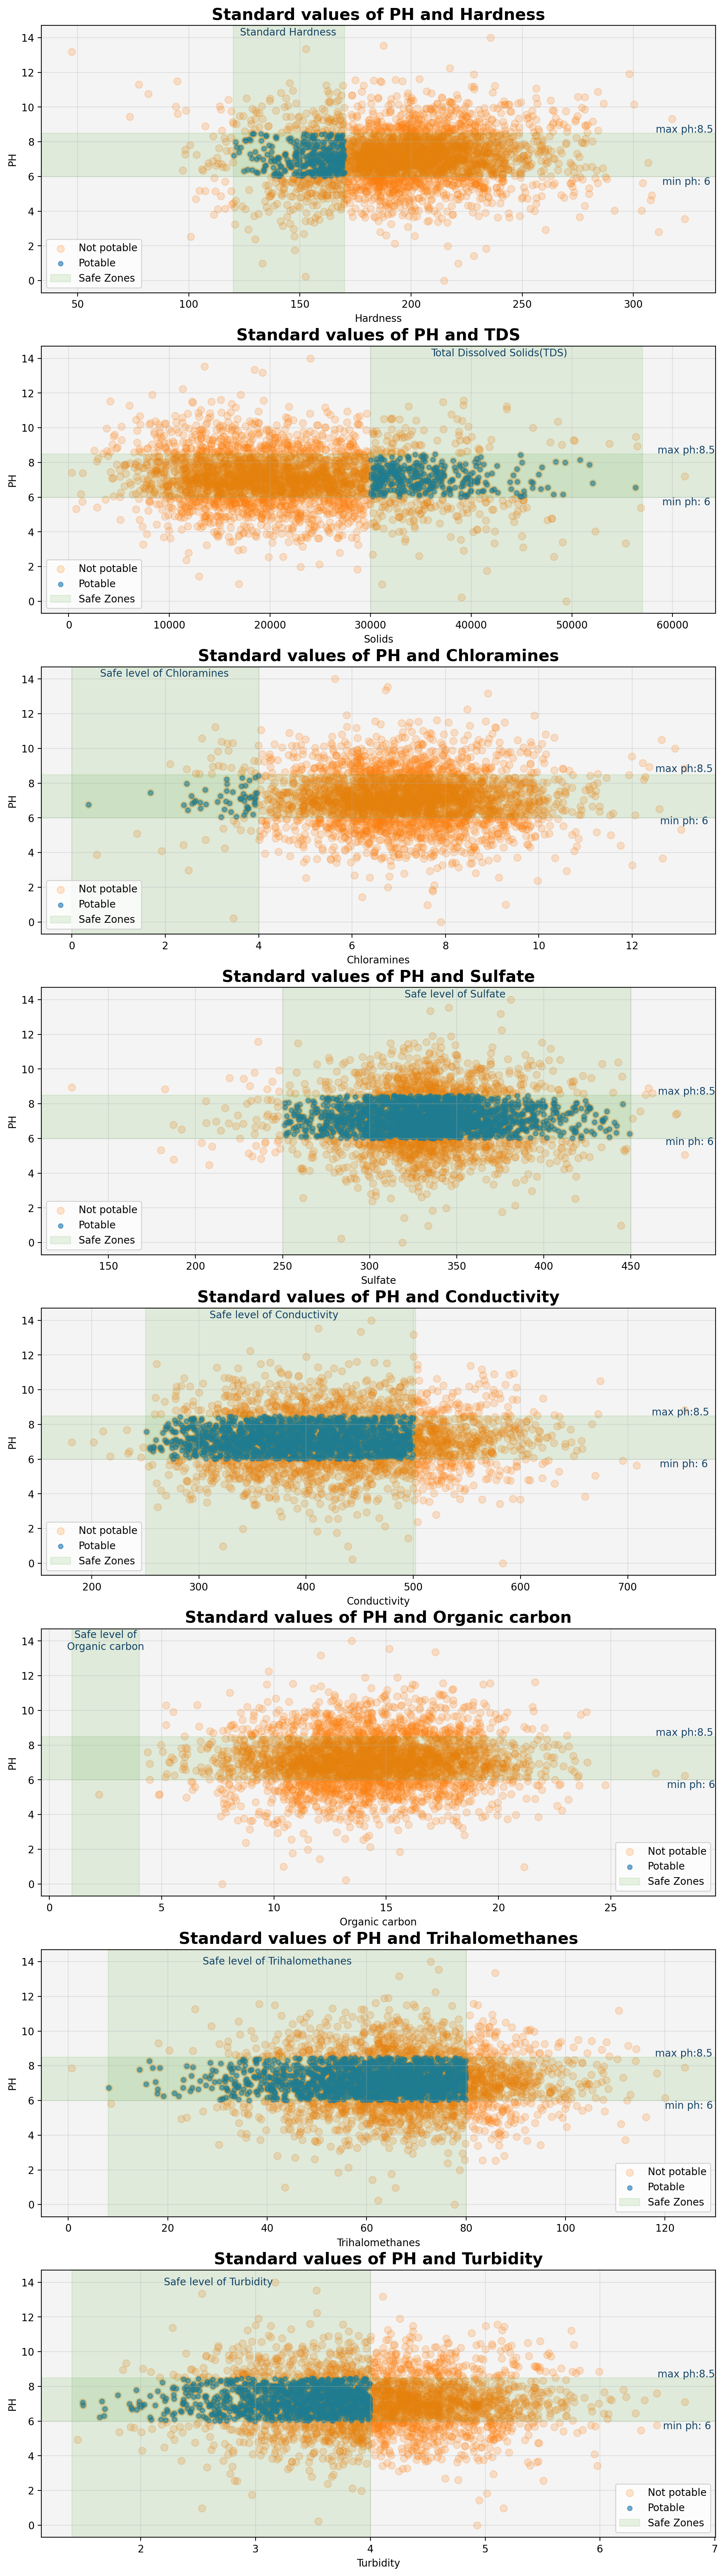

In [29]:
fig,axs=plt.subplots(8,1,figsize=(12,45),dpi=200)
axs[0].set_title("Standard values of PH and Hardness",fontsize=16,fontweight="bold",loc='center')
axs[0].scatter(finall_df["Hardness"],finall_df["ph"],s=50,alpha=0.2,color="#ff7f0e",label="Not potable")
axs[0].scatter(finall_df.loc[ph_hardness,"Hardness"],finall_df.loc[ph_hardness,"ph"],c="#1f77b4",s=20,alpha=0.6,label="Potable")
axs[0].set_xlabel("Hardness")
axs[0].set_ylabel("PH")
axs[0].axvspan(120,170,color="#269603",alpha=0.10)
axs[0].axhspan(6,8.5,color="#269603",alpha=0.10,label="Safe Zones")
axs[0].text(310,8.7,"max ph:8.5",color="#114264",va="center",fontsize=10)
axs[0].text(313,5.7,"min ph: 6",color="#114264",va="center",fontsize=10)
axs[0].text(123,14.3,"Standard Hardness",color="#114264",va="center",fontsize=10)
axs[0].set_facecolor("#f4f4f4")
axs[0].grid(True,alpha=0.3)
axs[0].legend()

axs[1].set_title("Standard values of PH and TDS",fontsize=16,fontweight="bold",loc='center')
axs[1].scatter(finall_df["Solids"],finall_df["ph"],s=50,alpha=0.2,color="#ff7f0e",label="Not potable")
axs[1].scatter(finall_df.loc[ph_solids,"Solids"],finall_df.loc[ph_solids,"ph"],c="#1f77b4",s=20,alpha=0.6,label="Potable")
axs[1].set_xlabel("Solids")
axs[1].set_ylabel("PH")
axs[1].axvspan(30000,57000,color="#269603",alpha=0.10)
axs[1].axhspan(6,8.5,color="#269603",alpha=0.10,label="Safe Zones")
axs[1].text(58500,8.7,"max ph:8.5",color="#114264",va="center",fontsize=10)
axs[1].text(59000,5.7,"min ph: 6",color="#114264",va="center",fontsize=10)
axs[1].text(36000,14.3,"Total Dissolved Solids(TDS)",color="#114264",va="center",fontsize=10)
axs[1].set_facecolor("#f4f4f4")
axs[1].grid(True,alpha=0.3)
axs[1].legend(loc='lower left')

axs[2].set_title("Standard values of PH and Chloramines",fontsize=16,fontweight="bold",loc='center')
axs[2].scatter(finall_df["Chloramines"],finall_df["ph"],s=50,alpha=0.2,color="#ff7f0e",label="Not potable")
axs[2].scatter(finall_df.loc[ph_chloramines,"Chloramines"],finall_df.loc[ph_chloramines,"ph"],c="#1f77b4",s=20,alpha=0.6,label="Potable")
axs[2].set_xlabel("Chloramines")
axs[2].set_ylabel("PH")
axs[2].axvspan(0,4,color="#269603",alpha=0.10)
axs[2].axhspan(6,8.5,color="#269603",alpha=0.10,label="Safe Zones")
axs[2].text(12.5,8.8,"max ph:8.5",color="#114264",va="center",fontsize=10)
axs[2].text(12.6,5.8,"min ph: 6",color="#114264",va="center",fontsize=10)
axs[2].text(0.6,14.3,"Safe level of Chloramines",color="#114264",va="center",fontsize=10)
axs[2].set_facecolor("#f4f4f4")
axs[2].grid(True,alpha=0.3)
axs[2].legend(loc='lower left')

axs[3].set_title("Standard values of PH and Sulfate",fontsize=16,fontweight="bold",loc='center')
axs[3].scatter(finall_df["Sulfate"],finall_df["ph"],s=50,alpha=0.2,color="#ff7f0e",label="Not potable")
axs[3].scatter(finall_df.loc[ph_sulfate,"Sulfate"],finall_df.loc[ph_sulfate,"ph"],c="#1f77b4",s=20,alpha=0.6,label="Potable")
axs[3].set_xlabel("Sulfate")
axs[3].set_ylabel("PH")
axs[3].axvspan(250,450,color="#269603",alpha=0.10)
axs[3].axhspan(6,8.5,color="#269603",alpha=0.10,label="Safe Zones")
axs[3].text(465.5,8.7,"max ph:8.5",color="#114264",va="center",fontsize=10)
axs[3].text(470,5.8,"min ph: 6",color="#114264",va="center",fontsize=10)
axs[3].text(320,14.3,"Safe level of Sulfate",color="#114264",va="center",fontsize=10)
axs[3].set_facecolor("#f4f4f4")
axs[3].grid(True,alpha=0.3)
axs[3].legend(loc='lower left')

axs[4].set_title("Standard values of PH and Conductivity",fontsize=16,fontweight="bold",loc='center')
axs[4].scatter(finall_df["Conductivity"],finall_df["ph"],s=50,alpha=0.2,color="#ff7f0e",label="Not potable")
axs[4].scatter(finall_df.loc[ph_conductivity,"Conductivity"],finall_df.loc[ph_conductivity,"ph"],c="#1f77b4",s=20,alpha=0.6,label="Potable")
axs[4].set_xlabel("Conductivity")
axs[4].set_ylabel("PH")
axs[4].axvspan(250,502,color="#269603",alpha=0.10)
axs[4].axhspan(6,8.5,color="#269603",alpha=0.10,label="Safe Zones")
axs[4].text(722.5,8.7,"max ph:8.5",color="#114264",va="center",fontsize=10)
axs[4].text(730,5.7,"min ph: 6",color="#114264",va="center",fontsize=10)
axs[4].text(310,14.3,"Safe level of Conductivity",color="#114264",va="center",fontsize=10)
axs[4].set_facecolor("#f4f4f4")
axs[4].grid(True,alpha=0.3)
axs[4].legend(loc='lower left')

axs[5].set_title("Standard values of PH and Organic carbon",fontsize=16,fontweight="bold",loc='center')
axs[5].scatter(finall_df["Organic_carbon"],finall_df["ph"],s=50,alpha=0.2,color="#ff7f0e",label="Not potable")
axs[5].scatter(finall_df.loc[ph_carbon,"Organic_carbon"],finall_df.loc[ph_carbon,"ph"],c="#1f77b4",s=20,alpha=0.6,label="Potable")
axs[5].set_xlabel("Organic carbon")
axs[5].set_ylabel("PH")
axs[5].axvspan(1,4,color="#269603",alpha=0.10)
axs[5].axhspan(6,8.5,color="#269603",alpha=0.10,label="Safe Zones")
axs[5].text(27,8.7,"max ph:8.5",color="#114264",va="center",fontsize=10)
axs[5].text(27.5,5.7,"min ph: 6",color="#114264",va="center",fontsize=10)
axs[5].text(2.5,14,"Safe level of\nOrganic carbon",ha="center",color="#114264",va="center",fontsize=10)
axs[5].set_facecolor("#f4f4f4")
axs[5].grid(True,alpha=0.3)
axs[5].legend(loc='lower right')

axs[6].set_title("Standard values of PH and Trihalomethanes",fontsize=16,fontweight="bold",loc='center')
axs[6].scatter(finall_df["Trihalomethanes"],finall_df["ph"],s=50,alpha=0.2,color="#ff7f0e",label="Not potable")
axs[6].scatter(finall_df.loc[ph_trihalomethanes,"Trihalomethanes"],finall_df.loc[ph_trihalomethanes,"ph"],c="#1f77b4",s=20,alpha=0.6,label="Potable")
axs[6].set_xlabel("Trihalomethanes")
axs[6].set_ylabel("PH")
axs[6].axvspan(8,80,color="#269603",alpha=0.10)
axs[6].axhspan(6,8.5,color="#269603",alpha=0.10,label="Safe Zones")
axs[6].text(118,8.7,"max ph:8.5",color="#114264",va="center",fontsize=10)
axs[6].text(120,5.7,"min ph: 6",color="#114264",va="center",fontsize=10)
axs[6].text(27,14,"Safe level of Trihalomethanes",color="#114264",va="center",fontsize=10)
axs[6].set_facecolor("#f4f4f4")
axs[6].grid(True,alpha=0.3)
axs[6].legend(loc='lower right')

axs[7].set_title("Standard values of PH and Turbidity",fontsize=16,fontweight="bold",loc='center')
axs[7].scatter(finall_df["Turbidity"],finall_df["ph"],s=50,alpha=0.2,color="#ff7f0e",label="Not potable")
axs[7].scatter(finall_df.loc[ph_turbidity,"Turbidity"],finall_df.loc[ph_turbidity,"ph"],c="#1f77b4",s=20,alpha=0.6,label="Potable")
axs[7].set_xlabel("Turbidity")
axs[7].set_ylabel("PH")
axs[7].axvspan(1.4,4,color="#269603",alpha=0.10)
axs[7].axhspan(6,8.5,color="#269603",alpha=0.10,label="Safe Zones")
axs[7].text(6.5,8.7,"max ph:8.5",color="#114264",va="center",fontsize=10)
axs[7].text(6.55,5.7,"min ph: 6",color="#114264",va="center",fontsize=10)
axs[7].text(2.2,14,"Safe level of Turbidity",color="#114264",va="center",fontsize=10)
axs[7].set_facecolor("#f4f4f4")
axs[7].grid(True,alpha=0.3)
axs[7].legend(loc='lower right')